<a href="https://colab.research.google.com/github/viswateja16/aiml_labs_projects/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=fd6cc981fb54465169f1a3e5f3830685bde5f8db3eb067771744613241095963
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [2]:
topic1 = 'Giraffe'
topic2 = 'Elephant'

wikipedia.set_lang('en')

eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

wikipedia.set_lang('fr')

fr1 = wikipedia.page(topic1).content
fr2 = wikipedia.page(topic2).content

PageError: Page id "graffer" does not match any pages. Try another id!

In [3]:
topic1 = "Giraffe"
topic2 = "Elephant"

In [4]:
import wikipedia

# English articles
wikipedia.set_lang('en')
eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

# French articles
wikipedia.set_lang('fr')
fr1 = wikipedia.page(topic1).content
fr2 = wikipedia.page(topic2).content

PageError: Page id "graffer" does not match any pages. Try another id!

In [5]:
import wikipedia

# Correct topic names
topic1 = "Giraffe"
topic2 = "Elephant"

# English pages
wikipedia.set_lang('en')
eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content

# French pages
wikipedia.set_lang('fr')
fr1 = wikipedia.page("Girafe").content
fr2 = wikipedia.page("Éléphant").content

print(eng1[:200])
print(fr1[:200])

Giraffes (genus Giraffa) are large African hoofed mammals. They are the tallest living terrestrial animals and the largest ruminants on Earth. They are classified under the family Giraffidae, along wi
Les girafes (Giraffa) sont un genre de mammifères artiodactyles ruminants, de la famille des Giraffidés. Elles vivent dans les savanes africaines et sont répandues du Tchad jusqu'en Afrique du Sud. De


In [6]:
fr1 = wikipedia.page("Girafe").content
fr2 = wikipedia.page("Éléphant").content

In [7]:
print(topic1)

Giraffe


In [8]:
import re

def cleanup(text):
    text = text.lower()                 # convert to lowercase
    text = re.sub('[^a-z]+','',text)    # remove symbols and numbers
    return text

In [9]:
eng1 = cleanup(eng1)
eng2 = cleanup(eng2)
fr1 = cleanup(fr1)
fr2 = cleanup(fr2)

In [10]:
print(eng1[:200])

giraffesgenusgiraffaarelargeafricanhoofedmammalstheyarethetallestlivingterrestrialanimalsandthelargestruminantsonearththeyareclassifiedunderthefamilygiraffidaealongwiththeirclosestextantrelativetheoka


In [11]:
from nltk.util import ngrams

In [12]:
bigrams = list(ngrams(eng1,2))
print(bigrams[:20])

[('g', 'i'), ('i', 'r'), ('r', 'a'), ('a', 'f'), ('f', 'f'), ('f', 'e'), ('e', 's'), ('s', 'g'), ('g', 'e'), ('e', 'n'), ('n', 'u'), ('u', 's'), ('s', 'g'), ('g', 'i'), ('i', 'r'), ('r', 'a'), ('a', 'f'), ('f', 'f'), ('f', 'a'), ('a', 'a')]


In [13]:
from collections import Counter

freq = Counter(bigrams)
print(freq.most_common(10))

[(('t', 'h'), 848), (('h', 'e'), 690), (('e', 's'), 683), (('i', 'n'), 598), (('a', 'n'), 550), (('e', 'r'), 482), (('r', 'e'), 455), (('r', 'a'), 438), (('a', 'l'), 407), (('n', 'd'), 397)]


In [14]:
import pandas as pd

df = pd.DataFrame(freq.most_common(20))
df.columns = ['Bigram','Frequency']
print(df)

    Bigram  Frequency
0   (t, h)        848
1   (h, e)        690
2   (e, s)        683
3   (i, n)        598
4   (a, n)        550
5   (e, r)        482
6   (r, e)        455
7   (r, a)        438
8   (a, l)        407
9   (n, d)        397
10  (s, t)        379
11  (o, n)        364
12  (a, t)        353
13  (e, a)        351
14  (n, g)        339
15  (e, n)        329
16  (a, r)        324
17  (t, i)        322
18  (i, r)        321
19  (n, t)        309


TypeError: 'value' must be an instance of str or bytes, not a tuple

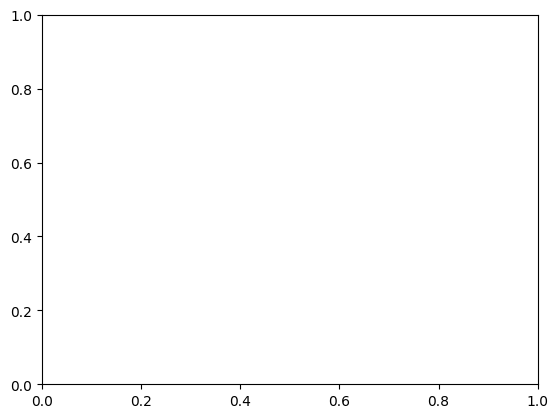

In [15]:
import matplotlib.pyplot as plt

plt.bar(df['Bigram'], df['Frequency'])
plt.xticks(rotation=90)
plt.show()

In [16]:
('e','l')
('l','e')
('e','p')

('e', 'p')

In [17]:
df['Bigram'] = df['Bigram'].apply(lambda x: ''.join(x))

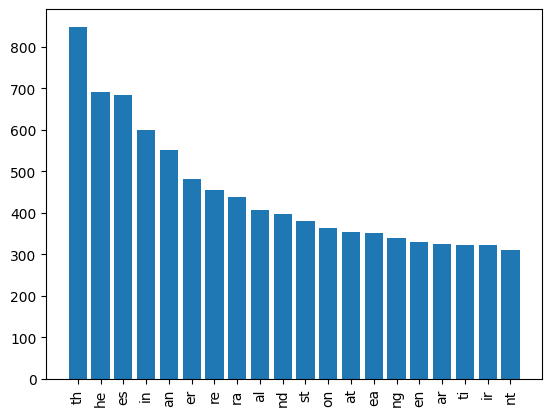

In [18]:
import matplotlib.pyplot as plt

df['Bigram'] = df['Bigram'].apply(lambda x: ''.join(x))

plt.bar(df['Bigram'], df['Frequency'])
plt.xticks(rotation=90)
plt.show()

In [19]:
('e','l')

('e', 'l')

In [20]:
"el"

'el'

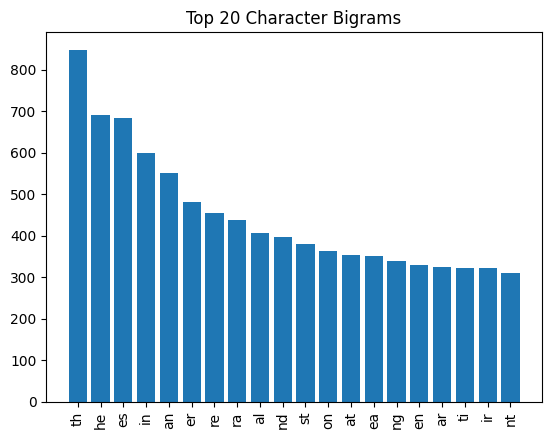

In [21]:
import matplotlib.pyplot as plt

df = pd.DataFrame(freq.most_common(20))
df.columns = ['Bigram','Frequency']

df['Bigram'] = df['Bigram'].apply(lambda x: ''.join(x))

plt.bar(df['Bigram'], df['Frequency'])
plt.xticks(rotation=90)
plt.title("Top 20 Character Bigrams")
plt.show()

In [22]:
eng1_bigrams = list(ngrams(eng1,2))
eng2_bigrams = list(ngrams(eng2,2))
fr1_bigrams = list(ngrams(fr1,2))
fr2_bigrams = list(ngrams(fr2,2))

In [23]:
eng1_freq = Counter(eng1_bigrams)
eng2_freq = Counter(eng2_bigrams)
fr1_freq = Counter(fr1_bigrams)
fr2_freq = Counter(fr2_bigrams)

In [24]:
all_bigrams = list(set(eng1_bigrams + eng2_bigrams + fr1_bigrams + fr2_bigrams))

In [25]:
def create_vector(freq_dict, bigram_list):
    return [freq_dict.get(b,0) for b in bigram_list]

In [26]:
v_eng1 = create_vector(eng1_freq, all_bigrams)
v_eng2 = create_vector(eng2_freq, all_bigrams)
v_fr1 = create_vector(fr1_freq, all_bigrams)
v_fr2 = create_vector(fr2_freq, all_bigrams)

In [27]:
from numpy.linalg import norm
import numpy as np

def cosine_similarity(a,b):
    return np.dot(a,b)/(norm(a)*norm(b))

In [28]:
print("English similarity:", cosine_similarity(v_eng1,v_eng2))
print("French similarity:", cosine_similarity(v_fr1,v_fr2))

English similarity: 0.9514697749542507
French similarity: 0.963916310463989


In [29]:
docs = {
    "Eng_Giraffe": v_eng1,
    "Eng_Elephant": v_eng2,
    "Fr_Giraffe": v_fr1,
    "Fr_Elephant": v_fr2
}

names = list(docs.keys())
vectors = list(docs.values())

similarity_matrix = []

for i in range(len(vectors)):
    row = []
    for j in range(len(vectors)):
        sim = cosine_similarity(vectors[i], vectors[j])
        row.append(sim)
    similarity_matrix.append(row)

In [30]:
import pandas as pd

sim_df = pd.DataFrame(similarity_matrix, index=names, columns=names)
print(sim_df)

              Eng_Giraffe  Eng_Elephant  Fr_Giraffe  Fr_Elephant
Eng_Giraffe      1.000000      0.951470    0.768707     0.739763
Eng_Elephant     0.951470      1.000000    0.734920     0.759905
Fr_Giraffe       0.768707      0.734920    1.000000     0.963916
Fr_Elephant      0.739763      0.759905    0.963916     1.000000


In [31]:
docs = {
    "Eng_Giraffe": v_eng1,
    "Eng_Elephant": v_eng2,
    "Fr_Giraffe": v_fr1,
    "Fr_Elephant": v_fr2
}

names = list(docs.keys())
vectors = list(docs.values())

similarity_matrix = []

for i in range(len(vectors)):
    row = []
    for j in range(len(vectors)):
        sim = cosine_similarity(vectors[i], vectors[j])
        row.append(sim)
    similarity_matrix.append(row)

In [33]:
import pandas as pd

sim_df = pd.DataFrame(similarity_matrix, index=names, columns=names)
print(sim_df)

              Eng_Giraffe  Eng_Elephant  Fr_Giraffe  Fr_Elephant
Eng_Giraffe      1.000000      0.951470    0.768707     0.739763
Eng_Elephant     0.951470      1.000000    0.734920     0.759905
Fr_Giraffe       0.768707      0.734920    1.000000     0.963916
Fr_Elephant      0.739763      0.759905    0.963916     1.000000


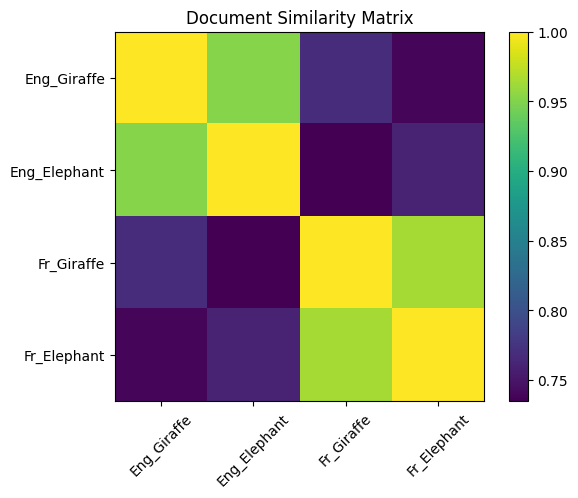

In [34]:
import matplotlib.pyplot as plt

plt.imshow(sim_df)
plt.colorbar()

plt.xticks(range(len(names)), names, rotation=45)
plt.yticks(range(len(names)), names)

plt.title("Document Similarity Matrix")
plt.show()